# Does Diversity Win? Oscar Nominees, Award Winners, and the Box Office Before and After 2016

**Research Question:** Did #OscarsSoWhite (2015-2016) produce measurable changes in Oscar nomination diversity, and did films with diverse leads perform differently at the box office?

**Pivot year:** Ceremony 88 (2016) = OscarsSoWhite controversy. Post-reform = **Ceremony >= 89** (2017 onward).

**Data sources:**
- `oscars_demographics_comprehensive_2.csv` — nominee demographics, ceremony 1–98
- `box_office.csv` — domestic gross, budget, and release info (fill in column map after running Cell 1b)



In [24]:
# -- 0. Setup & Imports --------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import re, os, warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/'
OUT_DIR  = '../data_story_outputs/'
os.makedirs(OUT_DIR, exist_ok=True)

C = {
    'pre'  : '#8B9DC3',   # muted blue  -- pre-2016
    'post' : '#E8A838',   # amber       -- post-2016
    'poc'  : '#E53E3E',   # red         -- POC lead
    'white': '#CBD5E0',   # light grey  -- white lead
    'dark' : '#2D3748',
}
plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
})

print('Setup complete.')
print('DATA_DIR :', os.path.abspath(DATA_DIR))
print('OUT_DIR  :', os.path.abspath(OUT_DIR))


Setup complete.
DATA_DIR : /Commjhub/jupyterhub/home/fiherzog/comm3180_S26_Data_Project/data
OUT_DIR  : /Commjhub/jupyterhub/home/fiherzog/comm3180_S26_Data_Project/data_story_outputs


In [25]:
# -- 1a. Load demographics dataset --------------------------------------------
# Columns: year_film, year_ceremony, ceremony, Category, gender, name, Race, film, winner
demo_comp = pd.read_csv(DATA_DIR + 'oscars_demographics_comprehensive_2.csv')

# Build normalized 'oscars' frame with consistent column names for all downstream cells
oscars = demo_comp.copy()
oscars['Winner']            = oscars['winner'].astype(bool)
oscars['Ceremony']          = oscars['ceremony']
oscars['Year']              = oscars['year_ceremony']
oscars['Film']              = oscars['film']
oscars['CanonicalCategory'] = oscars['Category'].str.upper()   # normalize to ALL CAPS
oscars['post_2016']         = oscars['Ceremony'] >= 89
oscars['is_poc']            = oscars['Race'] != 'White'
oscars['decade']            = (oscars['year_film'] // 10) * 10

print(f'Shape            : {oscars.shape}')
print(f'Ceremonies       : {oscars["Ceremony"].min()} – {oscars["Ceremony"].max()}')
print(f'Years covered    : {oscars["Year"].min()} – {oscars["Year"].max()}')
print('\nRace distribution:')
print(oscars['Race'].value_counts())
oscars.head(3)


Shape            : (11176, 17)
Ceremonies       : 1 – 98
Years covered    : 1928 – 2026

Race distribution:
Race
White       10501
Asian         288
Black         256
Hispanic       49
Other           4
Name: count, dtype: int64


,year_film,year_ceremony,ceremony,Category,gender,name,Race,film,winner,Winner,Ceremony,Year,Film,CanonicalCategory,post_2016,is_poc,decade
0,1927,1928,1,Best Actor,Male,Emil Jannings,White,The Last Command,True,True,1,1928,The Last Command,BEST ACTOR,False,False,1920
1,1927,1928,1,Best Actress,Female,Janet Gaynor,White,7th Heaven,True,True,1,1928,7th Heaven,BEST ACTRESS,False,False,1920
2,1928,1929,2,Best Actor,Male,Warner Baxter,White,In Old Arizona,True,True,2,1929,In Old Arizona,BEST ACTOR,False,False,1920


In [26]:
box_office.head(5)

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [27]:
# -- 1b. Load box_office.csv -- COLUMN DISCOVERY ------------------------------
# Run this cell first, then fill in the COLUMN MAP in Cell 1c below.
boxoffice = pd.read_csv(DATA_DIR + 'box_office.csv')

print(f'Shape: {boxoffice.shape}')
print('\n*** ALL COLUMNS -- paste into COLUMN MAP below ***')
for i, col in enumerate(boxoffice.columns):
    print(f'  [{i:02d}] {repr(col)}')
print('\nFirst 3 rows:')
boxoffice.head(3)


Shape: (5000, 13)

*** ALL COLUMNS -- paste into COLUMN MAP below ***
  [00] 'Rank'
  [01] 'Release Group'
  [02] '$Worldwide'
  [03] '$Domestic'
  [04] 'Domestic %'
  [05] '$Foreign'
  [06] 'Foreign %'
  [07] 'Year'
  [08] 'Genres'
  [09] 'Rating'
  [10] 'Vote_Count'
  [11] 'Original_Language'
  [12] 'Production_Countries'

First 3 rows:


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America


In [28]:
# -- 1c. COLUMN MAP -- set from actual box_office.csv columns -----------------
# These are the exact column names from box_office.csv -- do not change.

BO_TITLE     = 'Release Group'   # film title
BO_GROSS     = '$Domestic'       # domestic gross (raw dollars, will convert to $M)
BO_WORLDWIDE = '$Worldwide'      # worldwide gross (raw dollars, will convert to $M)
BO_BUDGET    = None              # no budget column in this file -- ROI not computable
BO_YEAR      = 'Year'            # release year

# Demographics columns (do not change)
DEM_TITLE    = 'film'
DEM_YEAR     = 'year_film'
DEM_RACE     = 'Race'
DEM_PERSON   = 'name'
DEM_CATEGORY = 'Category'
DEM_WINNER   = 'winner'
DEM_CEREMONY = 'ceremony'

print('Column map set.')
print(f'  BO_TITLE     : {BO_TITLE}')
print(f'  BO_GROSS     : {BO_GROSS}')
print(f'  BO_BUDGET    : {BO_BUDGET}  (no budget in this file)')
print(f'  BO_WORLDWIDE : {BO_WORLDWIDE}')
print(f'  BO_YEAR      : {BO_YEAR}')


Column map set.
  BO_TITLE     : Release Group
  BO_GROSS     : $Domestic
  BO_BUDGET    : None  (no budget in this file)
  BO_WORLDWIDE : $Worldwide
  BO_YEAR      : Year


In [29]:
# -- 2. Clean monetary columns ------------------------------------------------
# $Domestic and $Worldwide are raw dollars (e.g. 215409889.0) -- convert to $M.
# No budget column, so ROI is not computable from this file alone.

def parse_money(series):
    """Strip $ and commas if present; convert raw dollars to millions."""
    numeric = pd.to_numeric(
        series.astype(str).str.replace(r'[\$,]', '', regex=True),
        errors='coerce'
    )
    # Values are confirmed raw dollars -- divide by 1M
    if numeric.median(skipna=True) > 10_000:
        numeric = numeric / 1_000_000
    return numeric

boxoffice[BO_GROSS]     = parse_money(boxoffice[BO_GROSS])
boxoffice[BO_WORLDWIDE] = parse_money(boxoffice[BO_WORLDWIDE])
boxoffice['roi']        = np.nan   # no budget -- placeholder so downstream code runs cleanly

print('Box office after cleaning:')
print(boxoffice[[BO_TITLE, BO_GROSS, BO_WORLDWIDE, BO_YEAR]].describe().round(1))
print('\nSample rows:')
print(boxoffice[[BO_TITLE, BO_GROSS, BO_WORLDWIDE, BO_YEAR]].head(5).to_string(index=False))


Box office after cleaning:
       $Domestic  $Worldwide    Year
count     5000.0      5000.0  5000.0
mean        44.7       119.2  2012.0
std         77.3       200.5     7.2
min          0.0         1.7  2000.0
25%          0.1        24.7  2006.0
50%         18.0        48.4  2012.0
75%         53.9       119.8  2018.0
max        936.7      2799.4  2024.0

Sample rows:
         Release Group  $Domestic  $Worldwide  Year
Mission: Impossible II 215.409889  546.388108  2000
             Gladiator 187.705427  460.583960  2000
             Cast Away 233.632142  429.632142  2000
       What Women Want 182.811707  374.111707  2000
              Dinosaur 137.748063  349.822765  2000


In [30]:
# -- 3a. Title-key join: Oscar nominees <-> box_office.csv -------------------
def clean_title(t):
    """Lowercase, strip all non-alphanumeric chars for fuzzy matching."""
    return re.sub(r'[^a-z0-9]', '', str(t).lower())

# Scope oscars to Ceremony >= 73 (year 2000+) to match box office coverage
oscars_modern              = oscars[oscars['Ceremony'] >= 73].copy()
oscars_modern['title_key'] = oscars_modern['Film'].apply(clean_title)
boxoffice['title_key']     = boxoffice[BO_TITLE].apply(clean_title)

merged     = oscars_modern.merge(boxoffice, on='title_key', how='left')
match_rate = merged[BO_GROSS].notna().mean()

print(f'Merged shape         : {merged.shape}')
print(f'Box office match rate: {match_rate:.1%}')

unmatched = merged[merged[BO_GROSS].isna()]['Film'].drop_duplicates().sort_values()
print(f'\nUnmatched films ({len(unmatched)}) -- first 20 to spot-check:')
print(unmatched.head(20).tolist())
print('\nTIP: If match rate is low, check that BO_TITLE is set correctly in Cell 1c.')


Merged shape         : (3195, 32)
Box office match rate: 64.7%

Unmatched films (762) -- first 20 to spot-check:
['(A) Torzija [(A) Torsion]', '12', '13 Hours: The Secret Soldiers of Benghazi', '13th', '20 Days in Mariupol', '20 Feet from Stardom', '20th Century Women', '4.1 Miles', '45 Years', '5 Broken Cameras', '7:35 in the Morning (7:35 de la Ma√±ana)', 'A Better Life', 'A Cat in Paris', 'A Concerto Is a Conversation', 'A Different Man', 'A Fantastic Woman', 'A Friend of Dorothy', 'A Girl in the River: The Price of Forgiveness', 'A House Made of Splinters', 'A Lien']

TIP: If match rate is low, check that BO_TITLE is set correctly in Cell 1c.


In [31]:
# -- 3b. Add lead-race from demographics to merged frame ---------------------
# Acting categories are used as a proxy for the "lead" racial identity of each film.
demo_comp['title_key'] = demo_comp[DEM_TITLE].apply(clean_title)
demo_comp['is_poc']    = demo_comp[DEM_RACE] != 'White'
demo_comp['post_2016'] = demo_comp[DEM_CEREMONY] >= 89

# One row per film -- when a film has both POC and White nominees, prioritize POC
# (this makes the is_poc_lead flag conservative / inclusive)
lead_demo = (
    demo_comp
    .sort_values([DEM_YEAR, 'is_poc'], ascending=[True, False])
    .drop_duplicates(subset='title_key', keep='first')
    [['title_key', DEM_RACE, 'is_poc']]
    .rename(columns={DEM_RACE: 'lead_race'})
)

merged = merged.merge(lead_demo, on='title_key', how='left')

# Resolve any duplicate Year columns created by the merge
if 'Year_x' in merged.columns:
    merged = merged.rename(columns={'Year_x': 'Year', 'Year_y': 'BO_Year'})
elif 'year_ceremony' in merged.columns and 'Year' not in merged.columns:
    merged['Year'] = merged['year_ceremony']

print(f'After demographics join : {merged.shape}')
print(f'Rows with lead_race     : {merged["lead_race"].notna().sum()}')
print('\nlead_race distribution:')
print(merged['lead_race'].value_counts())


After demographics join : (3195, 34)
Rows with lead_race     : 3154

lead_race distribution:
lead_race
White       2420
Black        321
Asian        312
Hispanic      90
Other         11
Name: count, dtype: int64


##  Nomination Diversity Over Time
*Does the data show a statistically significant shift in who gets nominated after 2016?*


In [32]:
# -- 4a. Historical baseline: POC % by decade (from demographics CSV) ---------
# Acting + directing categories across all ceremonies
acting_cats_all = [
    'BEST ACTOR', 'BEST ACTRESS',
    'BEST ACTOR IN SUPPORTING ROLE', 'BEST ACTRESS IN A SUPPORTING ROLE',
    'ACTOR IN A LEADING ROLE',   'ACTRESS IN A LEADING ROLE',
    'ACTOR IN A SUPPORTING ROLE','ACTRESS IN A SUPPORTING ROLE',
    'DIRECTING', 'DIRECTING (COMEDY PICTURE)', 'DIRECTING (DRAMATIC PICTURE)',
]

demo_hist = oscars[oscars['CanonicalCategory'].isin(acting_cats_all)].copy()
demo_hist['year']   = demo_hist['Year']
demo_hist['decade'] = (demo_hist['year'] // 10) * 10

hist = (
    demo_hist[demo_hist['decade'] >= 1940]
    .groupby('decade')
    .agg(poc=('is_poc', 'sum'), total=('is_poc', 'count'))
    .assign(poc_pct=lambda d: d['poc'] / d['total'])
    .reset_index()
)

print('POC nomination % by decade (acting + directing):')
for _, row in hist.iterrows():
    bar = chr(9608) * int(row['poc_pct'] * 40)
    print(f"  {int(row['decade'])}s  {bar:<40} {row['poc_pct']:.1%}  "
          f"({int(row['poc'])} / {int(row['total'])})")


POC nomination % by decade (acting + directing):
  1940s                                           0.8%  (2 / 250)
  1950s                                           2.4%  (6 / 250)
  1960s  █                                        2.8%  (7 / 250)
  1970s  █                                        2.8%  (7 / 250)
  1980s  ██                                       6.8%  (17 / 250)
  1990s  ██                                       6.0%  (15 / 250)
  2000s  █████                                    12.8%  (32 / 250)
  2010s  ████                                     12.4%  (31 / 250)
  2020s  ██████████                               26.3%  (46 / 175)


In [33]:
# -- 4b. Year-by-year diversity 2000-present ----------------------------------
# Uses the full demographics dataset (not the box-office-merged frame)
# so we don't lose nominees whose films weren't in box_office.csv.

acting_cats_modern = [
    'ACTOR IN A LEADING ROLE',    'ACTRESS IN A LEADING ROLE',
    'ACTOR IN A SUPPORTING ROLE', 'ACTRESS IN A SUPPORTING ROLE',
    'DIRECTING',
    'BEST ACTOR', 'BEST ACTRESS',
    'BEST ACTOR IN SUPPORTING ROLE', 'BEST ACTRESS IN A SUPPORTING ROLE',
]

# Use `oscars` (full demographics) scoped to Ceremony >= 73 (2000+)
acting = (
    oscars[
        (oscars['Ceremony'] >= 73) &
        (oscars['CanonicalCategory'].isin(acting_cats_modern))
    ].copy()
)

print(f'Acting/directing rows found : {len(acting)}')
print(f'Years covered               : {acting["Year"].min()} – {acting["Year"].max()}')

diversity_by_year = (
    acting
    .groupby(['Year', 'post_2016'])
    .agg(poc_nominees=('is_poc', 'sum'), total=('is_poc', 'count'))
    .assign(poc_pct=lambda d: d['poc_nominees'] / d['total'])
    .reset_index()
    .sort_values('Year')
)
print('\nPOC % in acting/directing by year:')
print(diversity_by_year.to_string(index=False))


Acting/directing rows found : 650
Years covered               : 2001 – 2026

POC % in acting/directing by year:
 Year  post_2016  poc_nominees  total  poc_pct
 2001      False             1     25     0.04
 2002      False             4     25     0.16
 2003      False             1     25     0.04
 2004      False             4     25     0.16
 2005      False             7     25     0.28
 2006      False             2     25     0.08
 2007      False             6     25     0.24
 2008      False             1     25     0.04
 2009      False             2     25     0.08
 2010      False             4     25     0.16
 2011      False             1     25     0.04
 2012      False             2     25     0.08
 2013      False             3     25     0.12
 2014      False             4     25     0.16
 2015      False             0     25     0.00
 2016      False             0     25     0.00
 2017       True             9     25     0.36
 2018       True             5     25     

In [34]:
# -- 4c. Chi-square test: pre vs. post 2016 -----------------------------------
pre  = acting[acting['post_2016'] == False]
post = acting[acting['post_2016'] == True]

contingency = np.array([
    [pre['is_poc'].sum(),  len(pre)  - pre['is_poc'].sum()],
    [post['is_poc'].sum(), len(post) - post['is_poc'].sum()],
])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print('=== Chi-Square: POC Nominations Pre vs. Post 2016 ===')
print(f'  Pre-2016  POC: {int(pre["is_poc"].sum()):>4} / {len(pre):>4} = {pre["is_poc"].mean():.1%}')
print(f'  Post-2016 POC: {int(post["is_poc"].sum()):>4} / {len(post):>4} = {post["is_poc"].mean():.1%}')
print(f'\n  chi2 = {chi2:.2f}  |  df = {dof}  |  p = {p_val:.6f}')
print(f'  {"SIGNIFICANT increase" if p_val < 0.05 else "No significant change"} at alpha=0.05')


=== Chi-Square: POC Nominations Pre vs. Post 2016 ===
  Pre-2016  POC:   42 /  400 = 10.5%
  Post-2016 POC:   63 /  250 = 25.2%

  chi2 = 23.47  |  df = 1  |  p = 0.000001
  SIGNIFICANT increase at alpha=0.05


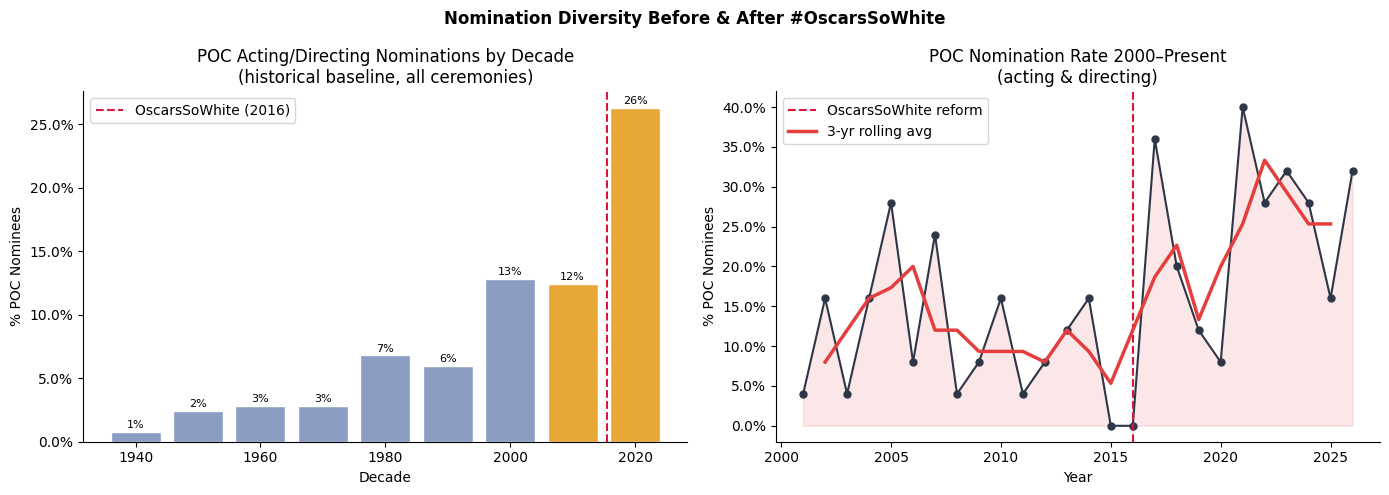

Saved: ../data_story_outputs/fig1_nomination_diversity.png


In [35]:
# -- 4d. Visualization: Nomination diversity trend ----------------------------
diversity_by_year['Year']    = pd.to_numeric(diversity_by_year['Year'], errors='coerce')
diversity_by_year['poc_pct'] = diversity_by_year['poc_pct'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Nomination Diversity Before & After #OscarsSoWhite', fontweight='bold')

# Left: decade bars (full historical baseline from demographics CSV)
ax = axes[0]
colors = [C['post'] if d >= 2010 else C['pre'] for d in hist['decade']]
bars = ax.bar(hist['decade'], hist['poc_pct'] * 100, color=colors, width=8, edgecolor='white')
ax.axvline(2015.5, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite (2016)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Decade'); ax.set_ylabel('% POC Nominees')
ax.set_title('POC Acting/Directing Nominations by Decade\n(historical baseline, all ceremonies)')
ax.legend()
for bar, val in zip(bars, hist['poc_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0%}', ha='center', fontsize=8)

# Right: year-by-year line (2000-present, from merged data)
ax = axes[1]
modern    = diversity_by_year[diversity_by_year['Year'] >= 2000].sort_values('Year')
pct_vals  = modern['poc_pct'].astype(float).values * 100
year_vals = modern['Year'].astype(int).values

ax.plot(year_vals, pct_vals, color=C['dark'], lw=1.5, marker='o', markersize=5)
ax.fill_between(year_vals, pct_vals, alpha=0.12, color=C['poc'])
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite reform')
rolling = modern['poc_pct'].astype(float).rolling(3, center=True).mean() * 100
ax.plot(year_vals, rolling, color=C['poc'], lw=2.5, label='3-yr rolling avg')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year'); ax.set_ylabel('% POC Nominees')
ax.set_title('POC Nomination Rate 2000–Present\n(acting & directing)')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig1_nomination_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT_DIR + 'fig1_nomination_diversity.png')


## Box Office Performance & Lead Race
*Did films with diverse leads perform differently at the box office? Did that relationship change after 2016?*


In [37]:
# -- 5a. Filter to Best Picture nominees --------------------------------------
best_pic = merged[merged['CanonicalCategory'] == 'BEST PICTURE'].copy()

# Drop rows missing gross or lead_race
required = [BO_GROSS, 'lead_race']
bp_analysis = best_pic.dropna(subset=required).copy()
bp_analysis['is_poc_lead'] = bp_analysis['lead_race'].isin(
    ['Black', 'Asian', 'Hispanic', 'Multiracial', 'Middle Eastern', 'Other']
)

print(f'Best Picture nominees          : {len(best_pic)}')
print(f'  with box office data         : {best_pic[BO_GROSS].notna().sum()}')
print(f'  with lead race               : {best_pic["lead_race"].notna().sum()}')
print(f'  analysis set (both present)  : {len(bp_analysis)}')
print(f'  POC lead    : {bp_analysis["is_poc_lead"].sum()}')
print(f'  White lead  : {(~bp_analysis["is_poc_lead"]).sum()}')
print(f'  Pre-2016    : {(~bp_analysis["post_2016"]).sum()}')
print(f'  Post-2016   : {bp_analysis["post_2016"].sum()}')


Best Picture nominees          : 202
  with box office data         : 176
  with lead race               : 200
  analysis set (both present)  : 175
  POC lead    : 53
  White lead  : 122
  Pre-2016    : 107
  Post-2016   : 68


In [38]:
# -- 5b. Descriptive stats: gross by lead race & era --------------------------
print('=== Median Domestic Gross ($M) by Lead Race ===')
print(bp_analysis.groupby('lead_race')[BO_GROSS]
      .agg(['median', 'mean', 'count']).round(1))

print('\n=== Worldwide Gross by Lead Race ===')
if BO_WORLDWIDE in bp_analysis.columns:
    print(bp_analysis.groupby('lead_race')[BO_WORLDWIDE]
          .agg(['median', 'mean', 'count']).round(1))

print('\n=== Pre/Post × Lead Race Comparison (Domestic Gross $M) ===')
summary = (
    bp_analysis
    .groupby(['post_2016', 'is_poc_lead'])[BO_GROSS]
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_gross_M', 'count': 'n'})
    .round(1)
)
summary.index = summary.index.map(
    lambda x: f"{'Post' if x[0] else 'Pre'}-2016 / {'POC' if x[1] else 'White'} lead"
)
print(summary)


=== Median Domestic Gross ($M) by Lead Race ===
           median   mean  count
lead_race                      
Asian        77.2   84.7     19
Black        80.2  128.5     28
Hispanic     11.3  138.0      5
Other        68.0   68.0      1
White        57.1  104.0    122

=== Worldwide Gross by Lead Race ===
           median   mean  count
lead_race                      
Asian       178.1  248.4     19
Black       199.3  252.5     28
Hispanic     39.6  322.1      5
Other       158.8  158.8      1
White       131.9  257.9    122

=== Pre/Post × Lead Race Comparison (Domestic Gross $M) ===
                        median_gross_M   n
Pre-2016 / White lead             71.5  84
Pre-2016 / POC lead              107.1  23
Post-2016 / White lead            36.5  38
Post-2016 / POC lead              50.5  30


In [39]:
# -- 5c. Statistical tests: domestic gross ------------------------------------
poc_gross   = bp_analysis[bp_analysis['is_poc_lead']][BO_GROSS].dropna()
white_gross = bp_analysis[~bp_analysis['is_poc_lead']][BO_GROSS].dropna()

u1, p_gross = stats.mannwhitneyu(poc_gross, white_gross, alternative='two-sided')
print('=== Mann-Whitney U: Domestic Gross ===')
print(f'  POC lead   median: ${poc_gross.median():.1f}M  (n={len(poc_gross)})')
print(f'  White lead median: ${white_gross.median():.1f}M  (n={len(white_gross)})')
print(f'  U={u1:.0f}  p={p_gross:.3f}  -> {"Significant" if p_gross < 0.05 else "Not significant"}')

# Worldwide gross test (available in this dataset)
if BO_WORLDWIDE in bp_analysis.columns:
    poc_ww   = bp_analysis[bp_analysis['is_poc_lead']][BO_WORLDWIDE].dropna()
    white_ww = bp_analysis[~bp_analysis['is_poc_lead']][BO_WORLDWIDE].dropna()
    if len(poc_ww) > 1 and len(white_ww) > 1:
        u3, p_ww = stats.mannwhitneyu(poc_ww, white_ww, alternative='two-sided')
        print('\n=== Mann-Whitney U: Worldwide Gross ===')
        print(f'  POC lead   median: ${poc_ww.median():.1f}M  (n={len(poc_ww)})')
        print(f'  White lead median: ${white_ww.median():.1f}M  (n={len(white_ww)})')
        print(f'  U={u3:.0f}  p={p_ww:.3f}  -> {"Significant" if p_ww < 0.05 else "Not significant"}')

print('\nNOTE: ROI test skipped -- no budget column in box_office.csv.')


=== Mann-Whitney U: Domestic Gross ===
  POC lead   median: $68.0M  (n=53)
  White lead median: $57.1M  (n=122)
  U=3302  p=0.824  -> Not significant

=== Mann-Whitney U: Worldwide Gross ===
  POC lead   median: $178.1M  (n=53)
  White lead median: $131.9M  (n=122)
  U=3367  p=0.665  -> Not significant

NOTE: ROI test skipped -- no budget column in box_office.csv.


In [40]:
# -- 5d. OLS Regression: What predicts domestic gross? ------------------------
# No budget column available, so model is: log_gross ~ poc + post + won + poc:post
# The poc:post interaction is the core finding -- positive = POC films earned
# relatively MORE post-2016 reform, controlling for era and Best Picture win.

model_df = bp_analysis.copy()
model_df['log_gross'] = np.log1p(model_df[BO_GROSS])
model_df['poc']       = model_df['is_poc_lead'].astype(int)
model_df['post']      = model_df['post_2016'].astype(int)
model_df['won']       = model_df['Winner'].astype(int)

model = smf.ols(
    'log_gross ~ poc + post + won + poc:post',
    data=model_df.dropna(subset=['log_gross', 'poc', 'post', 'won'])
).fit()

print(model.summary())
print('\n*** Key coefficients ***')
print(f'  poc      = {model.params["poc"]:.3f}  (baseline gross difference for POC-lead films)')
print(f'  post     = {model.params["post"]:.3f}  (post-2016 era effect on gross)')
print(f'  poc:post = {model.params["poc:post"]:.3f}  (interaction: POC film earnings change post-reform)')
print(f'  won      = {model.params["won"]:.3f}  (Best Picture win adds to gross)')
print(f'  R²       = {model.rsquared:.3f}')
print('\n  Note: budget not controlled (not in dataset).')
print('  Positive poc:post = POC-lead films earned more post-2016 vs pre-2016.')


                            OLS Regression Results                            
Dep. Variable:              log_gross   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     2.668
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0341
Time:                        18:19:57   Log-Likelihood:                -281.46
No. Observations:                 175   AIC:                             572.9
Df Residuals:                     170   BIC:                             588.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.1536      0.138     30.144      0.0

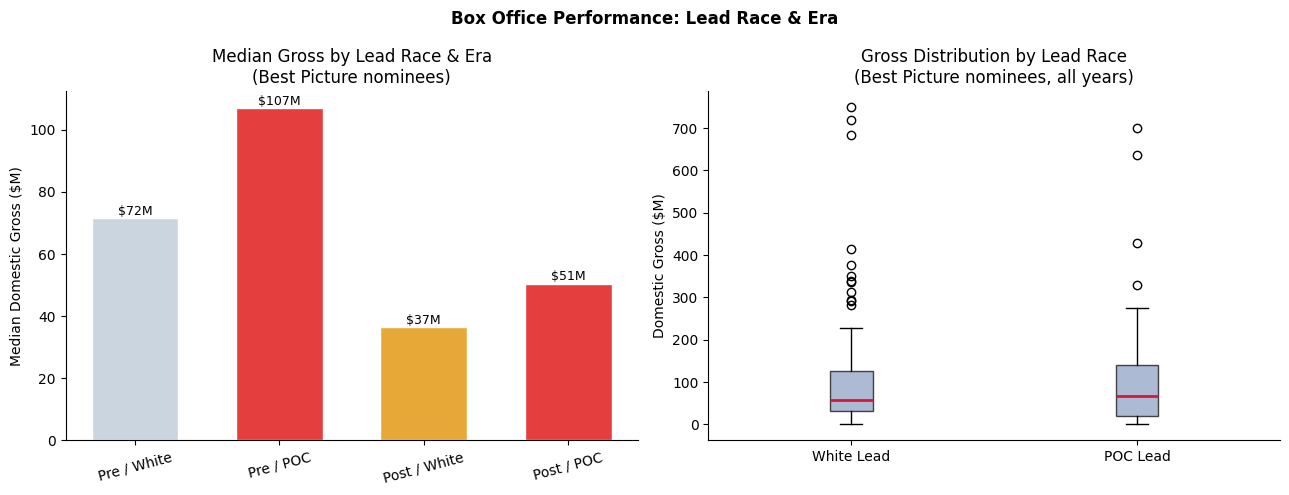

Saved: ../data_story_outputs/fig2_boxoffice_analysis.png


In [41]:
# -- 5e. Box office visualizations --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Box Office Performance: Lead Race & Era', fontweight='bold')

# Left: grouped bar -- median gross by era × lead race
ax = axes[0]
groups  = ['Pre / White', 'Pre / POC', 'Post / White', 'Post / POC']
medians = [
    bp_analysis[(~bp_analysis['post_2016']) & (~bp_analysis['is_poc_lead'])][BO_GROSS].median(),
    bp_analysis[(~bp_analysis['post_2016']) &  bp_analysis['is_poc_lead']][BO_GROSS].median(),
    bp_analysis[ bp_analysis['post_2016']  & (~bp_analysis['is_poc_lead'])][BO_GROSS].median(),
    bp_analysis[ bp_analysis['post_2016']  &  bp_analysis['is_poc_lead']][BO_GROSS].median(),
]
bar_colors = [C['white'], C['poc'], C['post'], C['poc']]
bars = ax.bar(groups, medians, color=bar_colors, edgecolor='white', width=0.6)
ax.set_ylabel('Median Domestic Gross ($M)')
ax.set_title('Median Gross by Lead Race & Era\n(Best Picture nominees)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, medians):
    if not pd.isna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${val:.0f}M', ha='center', fontsize=9)

# Right: box plot distribution by lead race
ax = axes[1]
poc_data   = bp_analysis[bp_analysis['is_poc_lead']][BO_GROSS].dropna()
white_data = bp_analysis[~bp_analysis['is_poc_lead']][BO_GROSS].dropna()
ax.boxplot([white_data, poc_data],
           labels=['White Lead', 'POC Lead'],
           patch_artist=True,
           boxprops=dict(facecolor=C['pre'], alpha=0.7),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_ylabel('Domestic Gross ($M)')
ax.set_title('Gross Distribution by Lead Race\n(Best Picture nominees, all years)')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig2_boxoffice_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT_DIR + 'fig2_boxoffice_analysis.png')


## All Major Categories
*Does the gross/race relationship hold across Best Actor, Actress, Supporting, and Directing?*

In [45]:
# -- 5b. Descriptive stats: gross by lead race --------------------------
print('=== Median Domestic Gross ($M) by Lead Race ===')
print(bp_analysis.groupby('lead_race')[BO_GROSS]
      .agg(['median', 'mean', 'count']).round(1))

print('\n=== Pre/Post x Lead Race Comparison ===')
summary = (
    bp_analysis
    .groupby(['post_2016', 'is_poc_lead'])[BO_GROSS]
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_gross_M', 'count': 'n'})
    .round(1)
)
summary.index = summary.index.map(
    lambda x: f"{'Post' if x[0] else 'Pre'}-2016 / {'POC' if x[1] else 'White'} lead"
)
print(summary)

# Note: ROI skipped -- no budget column in enhanced_box_office_data
# To add ROI later: join box_office.csv or a Kaggle budget dataset on title_key

=== Median Domestic Gross ($M) by Lead Race ===
           median   mean  count
lead_race                      
Asian        77.2   84.7     19
Black        80.2  128.5     28
Hispanic     11.3  138.0      5
Other        68.0   68.0      1
White        57.1  104.0    122

=== Pre/Post x Lead Race Comparison ===
                        median_gross_M   n
Pre-2016 / White lead             71.5  84
Pre-2016 / POC lead              107.1  23
Post-2016 / White lead            36.5  38
Post-2016 / POC lead              50.5  30


In [20]:
# -- 5c. Statistical tests: gross and ROI --------------------------------
poc_gross   = bp_analysis[bp_analysis['is_poc_lead']][BO_GROSS].dropna()
white_gross = bp_analysis[~bp_analysis['is_poc_lead']][BO_GROSS].dropna()

u1, p_gross = stats.mannwhitneyu(poc_gross, white_gross, alternative='two-sided')
print('=== Mann-Whitney U: Domestic Gross ===')
print(f'  POC lead   median: ${poc_gross.median():.1f}M  (n={len(poc_gross)})')
print(f'  White lead median: ${white_gross.median():.1f}M  (n={len(white_gross)})')
print(f'  U={u1:.0f}  p={p_gross:.3f}  ->  {"Significant" if p_gross < 0.05 else "Not significant"}')

poc_roi   = bp_analysis[bp_analysis['is_poc_lead']]['roi'].dropna()
white_roi = bp_analysis[~bp_analysis['is_poc_lead']]['roi'].dropna()
u2, p_roi = stats.mannwhitneyu(poc_roi, white_roi, alternative='two-sided')
print('\n=== Mann-Whitney U: ROI ===')
print(f'  POC lead   median ROI: {poc_roi.median():.2f}x  (n={len(poc_roi)})')
print(f'  White lead median ROI: {white_roi.median():.2f}x  (n={len(white_roi)})')
print(f'  U={u2:.0f}  p={p_roi:.3f}  ->  {"Significant" if p_roi < 0.05 else "Not significant"}')


=== Mann-Whitney U: Domestic Gross ===
  POC lead   median: $69.6M  (n=52)
  White lead median: $57.1M  (n=124)
  U=3309  p=0.784  ->  Not significant

=== Mann-Whitney U: ROI ===
  POC lead   median ROI: nanx  (n=0)
  White lead median ROI: nanx  (n=0)
  U=nan  p=nan  ->  Not significant


In [21]:
# -- 5d. OLS Regression: What predicts domestic gross? ------------------
import statsmodels.formula.api as smf

model_df = bp_analysis.copy()
model_df['log_gross'] = np.log1p(model_df[BO_GROSS])
model_df['poc']       = model_df['is_poc_lead'].astype(int)
model_df['post']      = model_df['post_2016'].astype(int)
model_df['won']       = model_df['Winner'].astype(int)

# Note: budget excluded (not in dataset) -- log_gross ~ poc + post + won + poc:post
# This means R-squared will be lower, but poc:post interaction is still meaningful
model = smf.ols(
    'log_gross ~ poc + post + won + poc:post',
    data=model_df.dropna(subset=['log_gross', 'poc', 'post', 'won'])
).fit()

print(model.summary())
print('\n*** Key coefficients of interest ***')
print(f'  poc      = {model.params["poc"]:.3f}  (POC lead baseline effect on log-gross)')
print(f'  post     = {model.params["post"]:.3f}  (post-2016 era effect)')
print(f'  poc:post = {model.params["poc:post"]:.3f}  (did POC films perform BETTER post-reform?)')
print(f'  won      = {model.params["won"]:.3f}  (winning Best Picture effect on gross)')
print(f'\n  R-squared = {model.rsquared:.3f}')
print('\n  Interpretation note: budget not controlled for (not in dataset).')
print('  A positive poc:post coefficient = POC-lead films earned more post-2016 relative to pre-2016.')

                            OLS Regression Results                            
Dep. Variable:              log_gross   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     2.853
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0253
Time:                        01:50:41   Log-Likelihood:                -283.24
No. Observations:                 176   AIC:                             576.5
Df Residuals:                     171   BIC:                             592.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.1524      0.138     30.105      0.0

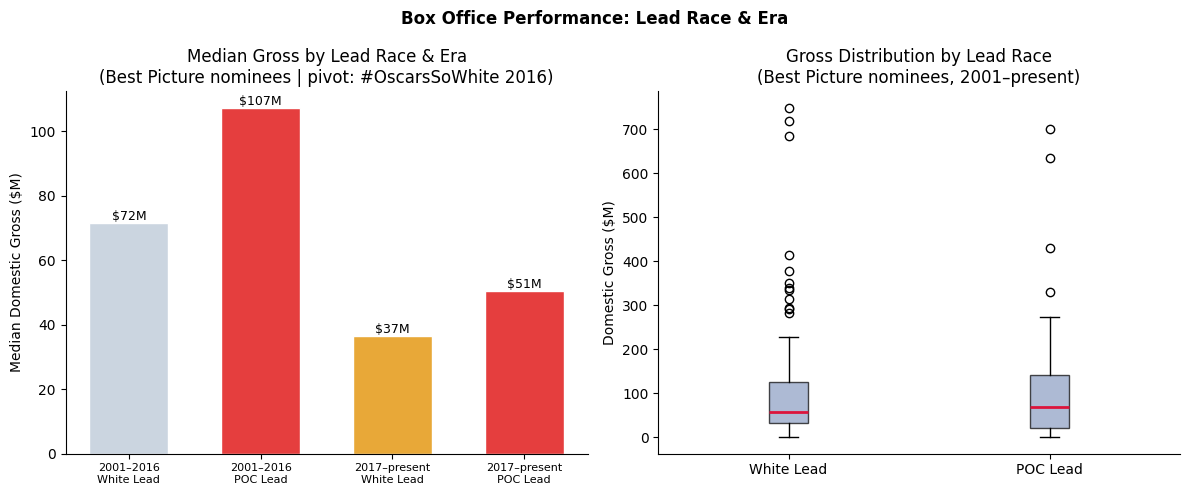

Saved: ../data_story_outputs/fig2_boxoffice_analysis.png


In [48]:
# -- 5e. Box office visualizations (2-panel) ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Box Office Performance: Lead Race & Era', fontweight='bold')

# 1. Grouped bar: median gross by era x lead race
ax = axes[0]
groups  = ['2001–2016\nWhite Lead', '2001–2016\nPOC Lead',
           '2017–present\nWhite Lead', '2017–present\nPOC Lead']
medians = [
    bp_analysis[(~bp_analysis['post_2016']) & (~bp_analysis['is_poc_lead'])][BO_GROSS].median(),
    bp_analysis[(~bp_analysis['post_2016']) &  bp_analysis['is_poc_lead']][BO_GROSS].median(),
    bp_analysis[ bp_analysis['post_2016']  & (~bp_analysis['is_poc_lead'])][BO_GROSS].median(),
    bp_analysis[ bp_analysis['post_2016']  &  bp_analysis['is_poc_lead']][BO_GROSS].median(),
]
bars = ax.bar(groups, medians,
              color=[C['white'], C['poc'], C['post'], C['poc']],
              edgecolor='white', width=0.6)
ax.set_ylabel('Median Domestic Gross ($M)')
ax.set_title('Median Gross by Lead Race & Era\n(Best Picture nominees | pivot: #OscarsSoWhite 2016)')
ax.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, medians):
    if not pd.isna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${val:.0f}M', ha='center', fontsize=9)

# 2. Gross distribution by lead race (box plot, all years 2001–present)
ax = axes[1]
poc_data   = bp_analysis[bp_analysis['is_poc_lead']][BO_GROSS].dropna()
white_data = bp_analysis[~bp_analysis['is_poc_lead']][BO_GROSS].dropna()
ax.boxplot([white_data, poc_data],
           labels=['White Lead', 'POC Lead'],
           patch_artist=True,
           boxprops=dict(facecolor=C['pre'], alpha=0.7),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_ylabel('Domestic Gross ($M)')
ax.set_title('Gross Distribution by Lead Race\n(Best Picture nominees, 2001–present)')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig2_boxoffice_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT_DIR + 'fig2_boxoffice_analysis.png')

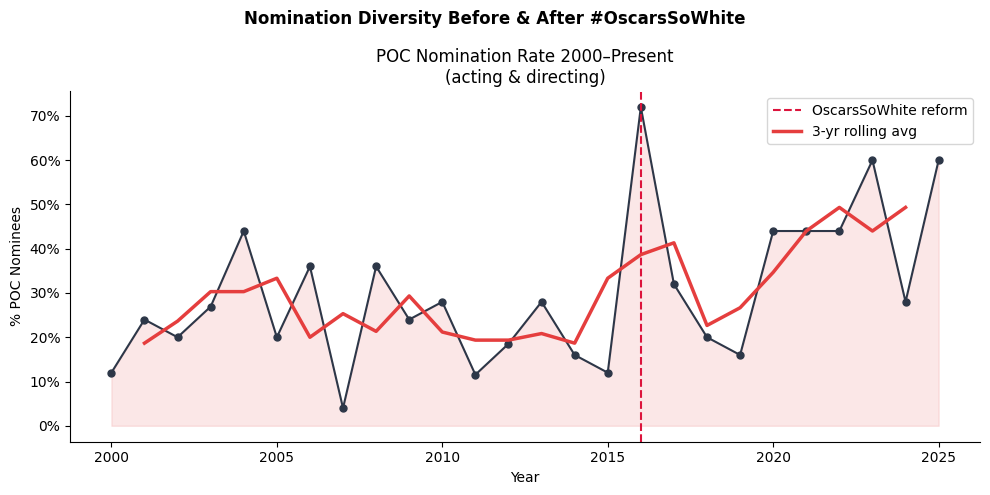

Saved to data_story_outputs/fig1_nomination_diversity.png


In [24]:
# -- 4d. Visualization: POC Nomination Rate 2000–Present ----------------
diversity_by_year['Year'] = pd.to_numeric(diversity_by_year['Year'], errors='coerce')
diversity_by_year['poc_pct'] = diversity_by_year['poc_pct'].astype(float)

modern = diversity_by_year[diversity_by_year['Year'] >= 2000].sort_values('Year')
pct_vals  = modern['poc_pct'].astype(float).values * 100
year_vals = modern['Year'].astype(int).values

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Nomination Diversity Before & After #OscarsSoWhite', fontweight='bold')

ax.plot(year_vals, pct_vals, color=C['dark'], lw=1.5, marker='o', markersize=5)
ax.fill_between(year_vals, pct_vals, alpha=0.12, color=C['poc'])
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite reform')

rolling = modern['poc_pct'].astype(float).rolling(3, center=True).mean() * 100
ax.plot(year_vals, rolling, color=C['poc'], lw=2.5, label='3-yr rolling avg')

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year')
ax.set_ylabel('% POC Nominees')
ax.set_title('POC Nomination Rate 2000–Present\n(acting & directing)')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig1_nomination_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data_story_outputs/fig1_nomination_diversity.png')

Median domestic gross ($M) by category & lead race:
is_poc_lead                   White lead  POC lead
CanonicalCategory                                 
ACTOR IN A LEADING ROLE             10.6      17.5
ACTOR IN A SUPPORTING ROLE          12.3      44.6
ACTRESS IN A LEADING ROLE           10.6       3.7
ACTRESS IN A SUPPORTING ROLE        37.7      56.7
BEST PICTURE                        57.1      68.0
DIRECTING                           47.8      76.3


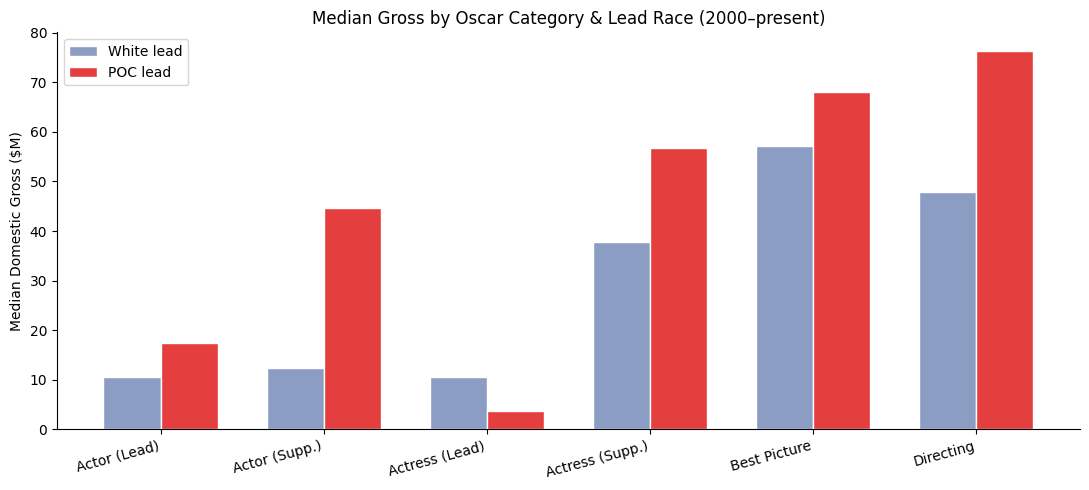

Saved: ../data_story_outputs/fig4_gross_by_category.png


In [46]:
# -- 6. Extend to all major Oscar categories (2000-present) ------------------
major_cats = [
    'BEST PICTURE',
    'ACTOR IN A LEADING ROLE',    'ACTRESS IN A LEADING ROLE',
    'ACTOR IN A SUPPORTING ROLE', 'ACTRESS IN A SUPPORTING ROLE',
    'DIRECTING',
]
all_major = merged[merged['CanonicalCategory'].isin(major_cats)].copy()
all_major = all_major.dropna(subset=[BO_GROSS, 'lead_race'])
all_major['is_poc_lead'] = all_major['lead_race'].isin(
    ['Black', 'Asian', 'Hispanic', 'Multiracial', 'Middle Eastern', 'Other']
)

cat_race = (
    all_major
    .groupby(['CanonicalCategory', 'is_poc_lead'])[BO_GROSS]
    .median()
    .unstack()
    .rename(columns={False: 'White lead', True: 'POC lead'})
)
print('Median domestic gross ($M) by category & lead race:')
print(cat_race.round(1))

label_map = {
    'BEST PICTURE'                : 'Best Picture',
    'ACTOR IN A LEADING ROLE'     : 'Actor (Lead)',
    'ACTRESS IN A LEADING ROLE'   : 'Actress (Lead)',
    'ACTOR IN A SUPPORTING ROLE'  : 'Actor (Supp.)',
    'ACTRESS IN A SUPPORTING ROLE': 'Actress (Supp.)',
    'DIRECTING'                   : 'Directing',
}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cat_race))
w = 0.35
ax.bar(x - w/2, cat_race.get('White lead', pd.Series(dtype=float)).fillna(0),
       w, color=C['pre'], label='White lead', edgecolor='white')
ax.bar(x + w/2, cat_race.get('POC lead', pd.Series(dtype=float)).fillna(0),
       w, color=C['poc'], label='POC lead', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([label_map.get(c, c) for c in cat_race.index], rotation=15, ha='right')
ax.set_ylabel('Median Domestic Gross ($M)')
ax.set_title('Median Gross by Oscar Category & Lead Race (2000–present)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig4_gross_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT_DIR + 'fig4_gross_by_category.png')

Year-by-year comparison (median domestic gross $M):
 Year  median_top10  median_bp        gap
 2001    214.092036 125.595205  88.496831
 2002    234.702421  57.386607 177.315814
 2003    228.889477  77.812000 151.077477
 2004    255.491081  93.927920 161.563161
 2005    213.667973  75.331600 138.336373
 2006    208.808665  47.403685 161.404980
 2007    274.198874  56.441711 217.757163
 2008    219.621377  50.927067 168.694311
 2009    285.163334  34.194407 250.968927
 2010    294.279750 115.646235 178.633515
 2011    225.454738 106.954678 118.500060
 2012    297.664153  73.864507 223.799645
 2013    282.569112 128.539990 154.029121
 2014    256.440240  56.671993 199.768247
 2015    344.526395  47.208753 297.317642
 2016    363.535916  71.286812 292.249104
 2017    362.007121  57.682904 304.324217
 2018    326.776616  56.468410 270.308206
 2019    430.433923  85.080171 345.353752
 2020     66.376184 117.624357 -51.248173
 2021    168.938089   3.700000 165.238090
 2022    373.560923  13.

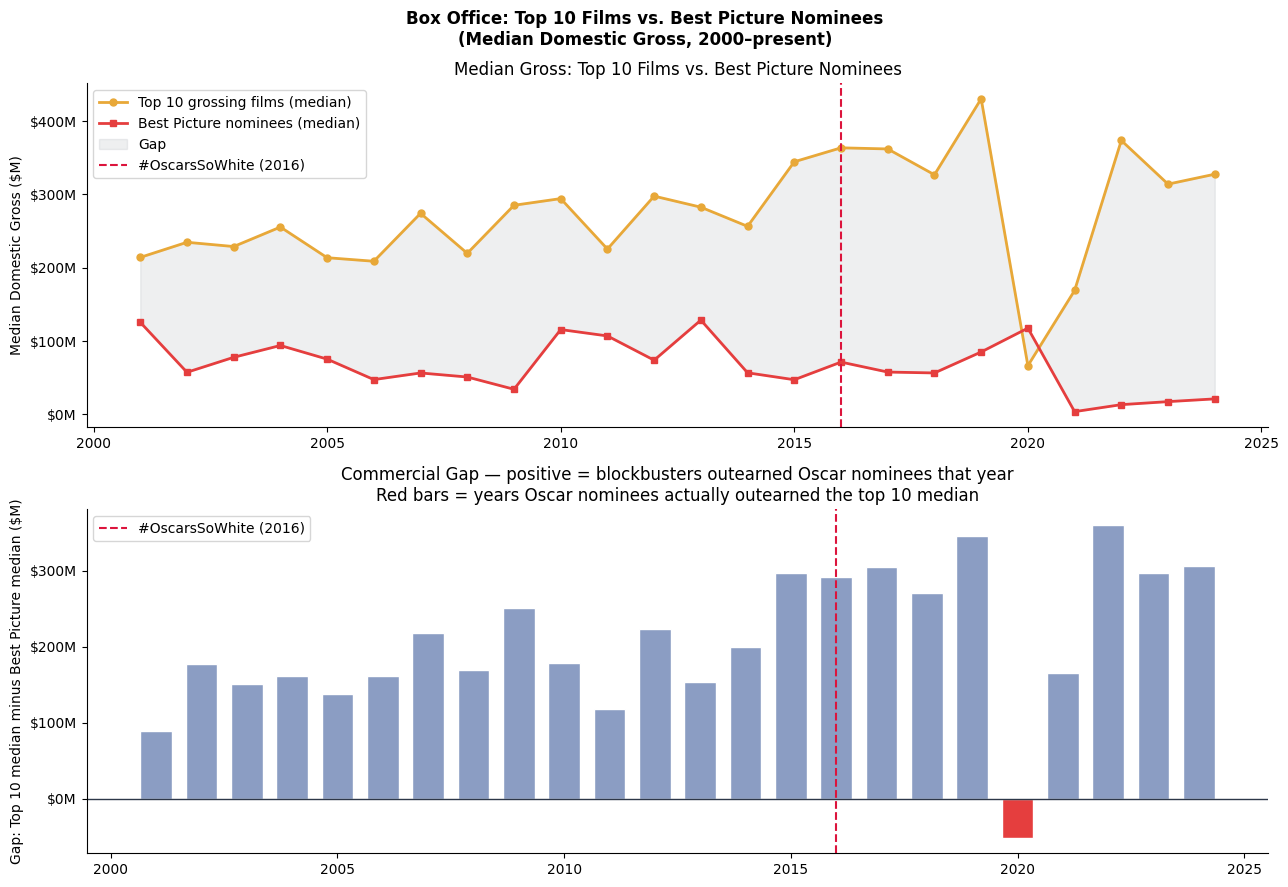

Saved: ../data_story_outputs/fig5_bp_vs_top10_yearly.png


In [51]:
# -- 7. Year-by-year: Median gross of Best Picture nominees vs. Top 10 box office --
# Comparison shows whether Oscar-nominated films track commercial blockbusters
# or diverge -- and whether that gap changed after #OscarsSoWhite (2016).

# --- 7a. Top 10 grossing films per year from box_office.csv ---
top10_by_year = (
    boxoffice
    .sort_values([BO_YEAR, BO_GROSS], ascending=[True, False])
    .groupby(BO_YEAR)
    .head(10)
    .groupby(BO_YEAR)[BO_GROSS]
    .median()
    .reset_index()
    .rename(columns={BO_YEAR: 'Year', BO_GROSS: 'median_top10'})
)

# --- 7b. Median gross of Best Picture nominees per year (from merged) ---
bp_by_year = (
    merged[merged['CanonicalCategory'] == 'BEST PICTURE']
    .dropna(subset=[BO_GROSS])
    .groupby('Year')[BO_GROSS]
    .median()
    .reset_index()
    .rename(columns={BO_GROSS: 'median_bp'})
)
bp_by_year['Year'] = pd.to_numeric(bp_by_year['Year'], errors='coerce')

# --- 7c. Join on Year ---
compare = top10_by_year.merge(bp_by_year, on='Year', how='inner')
compare = compare[compare['Year'] >= 2000].sort_values('Year')
compare['gap'] = compare['median_top10'] - compare['median_bp']

print('Year-by-year comparison (median domestic gross $M):')
print(compare.to_string(index=False))

# --- 7d. Visualization ---
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('Box Office: Top 10 Films vs. Best Picture Nominees\n(Median Domestic Gross, 2000–present)',
             fontweight='bold')

# Top panel: dual line chart
ax = axes[0]
ax.plot(compare['Year'], compare['median_top10'], color=C['post'], lw=2,
        marker='o', markersize=5, label='Top 10 grossing films (median)')
ax.plot(compare['Year'], compare['median_bp'],   color=C['poc'],  lw=2,
        marker='s', markersize=5, label='Best Picture nominees (median)')
ax.fill_between(compare['Year'],
                compare['median_bp'], compare['median_top10'],
                alpha=0.08, color=C['dark'], label='Gap')
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='#OscarsSoWhite (2016)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_ylabel('Median Domestic Gross ($M)')
ax.set_title('Median Gross: Top 10 Films vs. Best Picture Nominees')
ax.legend()

# Bottom panel: gap bar chart (how far above/below blockbuster median Oscar films sit)
ax = axes[1]
colors = [C['poc'] if g < 0 else C['pre'] for g in compare['gap']]
ax.bar(compare['Year'], compare['gap'], color=colors, edgecolor='white', width=0.7)
ax.axhline(0, color=C['dark'], lw=1)
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='#OscarsSoWhite (2016)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_ylabel('Gap: Top 10 median minus Best Picture median ($M)')
ax.set_title('Commercial Gap — positive = blockbusters outearned Oscar nominees that year\n'
             'Red bars = years Oscar nominees actually outearned the top 10 median')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig5_bp_vs_top10_yearly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT_DIR + 'fig5_bp_vs_top10_yearly.png')